# Kernel Linear (RBF)

## What was missing
- The `rbf_kernel(a, b)` function body
- Building the training kernel matrix `K = K(X, X)`
- Building the test-to-train kernel matrix `K_small = K(Xtest, X)`
- Prediction step `y_pred = K_small @ alpha`

In [1]:
# Completed RBF kernel implementation
import numpy as np

def rbf_kernel(a, b, length_scale=1.0):
    sq_norm_a = np.sum(a**2, axis=1)[:, None]
    sq_norm_b = np.sum(b**2, axis=1)[None, :]
    sq_dist = sq_norm_a + sq_norm_b - 2 * (a @ b.T)
    return np.exp(-sq_dist / (2 * length_scale**2))

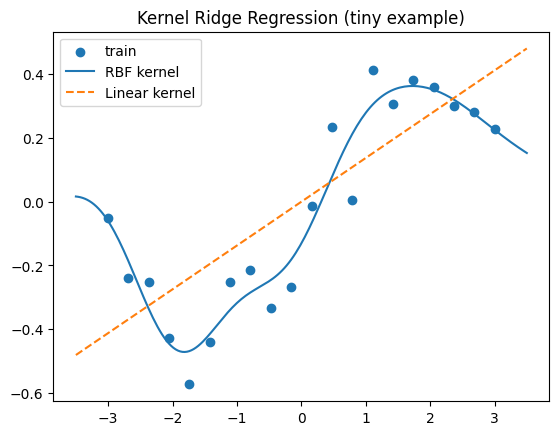

In [2]:
# End-to-end completed logic (same core flow as kernallinear_finished.py)
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
X = np.linspace(-3, 3, 20)[:, None]
y = 0.5*np.sin(X).ravel() + 0.15 * rng.normal(size=X.shape[0])

def rbf_kernel(a, b, length_scale=1.0):
    sq_norm_a = np.sum(a**2, axis=1)[:, None]
    sq_norm_b = np.sum(b**2, axis=1)[None, :]
    sq_dist = sq_norm_a + sq_norm_b - 2 * (a @ b.T)
    return np.exp(-sq_dist / (2 * length_scale**2))

def linear_kernel(a, b):
    return a @ b.T

K = rbf_kernel(X, X)
lam = 1e-2
alpha = np.linalg.solve(K + lam * np.eye(len(X)), y)

Xtest = np.linspace(-3.5, 3.5, 200)[:, None]
K_small = rbf_kernel(Xtest, X)
y_pred = K_small @ alpha

K_lin = linear_kernel(X, X)
alpha_lin = np.linalg.solve(K_lin + lam * np.eye(len(X)), y)
y_pred_lin = linear_kernel(Xtest, X) @ alpha_lin

plt.figure()
plt.scatter(X.ravel(), y, label='train')
plt.plot(Xtest.ravel(), y_pred, label='RBF kernel')
plt.plot(Xtest.ravel(), y_pred_lin, linestyle='--', label='Linear kernel')
plt.legend()
plt.title('Kernel Ridge Regression (tiny example)')
plt.show()